In [1]:
import pennylane as qp
qml = qp
import numpy as np

In [2]:
n_bits = 2
dev = qp.device("default.qubit", wires=n_bits, shots=None)
np.random.seed(41)

def build_hamiltonian():
    """Build the Hamiltonian.

    Returns:
        (qml.Hamiltonian): Hamiltonian operator.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    return qp.Hamiltonian([1, -1], [qp.PauliZ(0) @ qp.PauliZ(1), qp.PauliX(0) @ qp.PauliX(1)])

def run_vqe():
    """Run VQE algorithm with initial parameters defined by the user.

    Returns:
        array(float): Ground state energy of the Hamiltonian.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    @qp.qnode(dev)
    def strongly_entangling_ansatz(observable, params):
        qp.StronglyEntanglingLayers(weights=params, ranges=[3], wires=range(n_bits))
        
        return qp.expval(observable)

    def cost_function(observable, params):
        
        return strongly_entangling_ansatz(observable, params)

    def optimizer(observable, params):
        opt = qp.AdamOptimizer(stepsize=0.1)
        for _ in range(100):
            params = opt.step(lambda p: cost_function(observable, p), params)
            
        return params

    shape = qp.StronglyEntanglingLayers.shape(n_layers=1, n_wires=n_bits)
    rng = np.random.default_rng()
    params = rng.random(size=shape)
    params = qp.numpy.array(params, requires_grad=True)

    params = optimizer(build_hamiltonian(), params)
    
    return strongly_entangling_ansatz(build_hamiltonian(), params)

In [3]:
run_vqe()

tensor(-1.99989728, requires_grad=True)

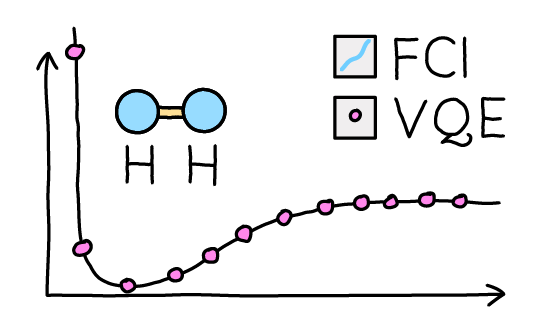

In [4]:
# Import the H2 molecule dataset
dataset = qp.data.load('qchem', folder_path="/tmp", molname="H2")[0]
# Define Hamiltonian and qubits
H, qubits = dataset.hamiltonian, len(dataset.hamiltonian.wires)
# The Hartree-Fock State
hf = dataset.hf_state
# Define the single and double excitations
singles, doubles = qp.qchem.excitations(electrons=2, orbitals=qubits)
num_params = len(singles) + len(doubles)

def hf_ansatz(params):
    """Build the Hartree-Fock ansatz.
    
    Args:
        params (np.array): An array with the angles of the single and double excitations.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    qp.AllSinglesDoubles(weights = params, 
                         wires = range(qubits), 
                         hf_state = hf, 
                         singles = singles, 
                         doubles = doubles)

dev = qp.device("default.qubit", wires=qubits)
@qp.qnode(dev, interface="autograd")
def cost_hf(params):
    """Build the cost function using the Hartree-Fock ansatz.
    Args:
        params (np.array): An array with the angles of the single and double excitations.

    Returns:
        (np.tensor): Energy of the Hamiltonian.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    hf_ansatz(params)
    
    return qp.expval(H)

In [5]:
# Import the H2 molecule dataset
dataset = qp.data.load('qchem', folder_path="/tmp", molname="H2")[0]
# Define Hamiltonian and qubits
H, qubits = dataset.hamiltonian, len(dataset.hamiltonian.wires)
# The Hartree-Fock State
hf = dataset.hf_state
# Define the single and double excitations
singles, doubles = qp.qchem.excitations(electrons=2, orbitals=qubits)
num_params = len(singles) + len(doubles)

def run_VQE_hf():
    """Executes the VQE optimizing the parameters of the Hartree-Fock ansatz.

    Returns:
        (np.array): an array with the optimized trainable parameters.
        (float): the ground state energy
    """
    ##################
    # YOUR CODE HERE #
    ##################
    params = qp.numpy.random.normal(0, np.pi, num_params, requires_grad=True)
    opt = qp.AdamOptimizer(stepsize = 0.1)
    
    for _ in range(100):
        params = opt.step(cost_hf, params)
    
    return params, cost_hf(params)

In [6]:
run_VQE_hf()

(tensor([-3.13348322,  3.13098384,  2.91735466], requires_grad=True),
 tensor(-1.13722804, requires_grad=True))